# 모두의 금융 AI 최종 실습
**실습 주제:** 삼성전자·NAVER 데이터 수집 → 전처리 → 수익률·위험 → 50:50 포트폴리오 → 의사결정나무 → LSTM 모델 --> 향후 5일 상승/하락 구면 예측

- 실행 환경: Windows Jupyter Notebook / Python 3.9~3.11 권장
- 심화 실습: LSTM 추가 실행
- 학습 목적의 예제이며 실제 투자 판단 자료가 아닙니다.

## 0. 패키지 설치
처음 실행할 때만 아래 셀의 주석을 해제하여 실행합니다. 설치 후 **Kernel → Restart Kernel**을 선택하세요.

TensorFlow 설치가 오래 걸리면 기본 실습을 먼저 진행하고 LSTM 부분은 나중에 실행해도 됩니다.

In [1]:
# 처음 한 번만 실행하세요.
# %pip install -U yfinance pandas numpy matplotlib scikit-learn
# %pip install tensorflow

In [2]:
# %pip install -U pykrx pandas numpy matplotlib scikit-learn

## 1. 라이브러리 불러오기 및 그래프 설정

In [65]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from pykrx import stock

# Windows 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.options.display.float_format = "{:,.4f}".format

## 2. 삼성전자와 NAVER 주가 데이터 수집

In [ ]:
# tickers는 파이썬의 딕셔너리(dictionary)입니다. 회사 이름을 key, 종목코드를 value로 저장
# datetime.today()는 현재 날짜와 시간을 가져옵니다.
# datetime.today()
#.strftime("%Y%m%d") 는 날짜를 문자열 형태로 변환합니다.
#
# %Y → 4자리 연도
# %m → 2자리 월
# %d → 2자리 일

#따라서 오늘이 2026년 8월 9일이라면:end_date는'20260809'가 됩니다.
# 마지막은 설정한 날짜를 화면에 확인하기 위한 코드입니다.
# 실행 결과는 현재 날짜 기준으로 다음과 같습니다.
# 조회 시작일: 20230101
# 조회 종료일: 20260809
# 단, 이 코드를 실행하려면 앞에서 datetime을 import해야 합니다.
# from datetime import datetime

In [67]:
# ----------------------------------------------------
# 1. 조회 종목과 기간 설정
# ----------------------------------------------------

tickers = {
    "삼성전자": "005930",
    "NAVER": "035420"
}

start_date = "20230101"

# 오늘 날짜를 YYYYMMDD 형태로 변환
end_date = datetime.today().strftime("%Y%m%d")

print("조회 시작일:", start_date)
print("조회 종료일:", end_date)

조회 시작일: 20230101
조회 종료일: 20260809


In [ ]:
# 1. 함수 정의
# def get_stock_data(
#     ticker,
#     start_date,
#     end_date,
#     max_retries=3,
#     wait_seconds=2
# ):

# 2. 마지막 오류를 저장할 변수 last_error = None
# 데이터 수집이 계속 실패했을 때 마지막으로 발생한 오류가 무엇인지 기억하기 위한 변수입니다.
# 처음에는 오류가 없으므로 None으로 설정합니다

In [68]:
# ----------------------------------------------------
# 2. pykrx 데이터 수집 함수
# ----------------------------------------------------

def get_stock_data(
    ticker,
    start_date,
    end_date,
    max_retries=3,
    wait_seconds=2
):
    """
    pykrx를 이용하여 개별 종목의 일별 OHLCV 데이터를 가져오는 함수
    """

    last_error = None

    for attempt in range(1, max_retries + 1):

        try:
            df = stock.get_market_ohlcv_by_date(
                fromdate=start_date,
                todate=end_date,
                ticker=ticker,
                freq="d",
                adjusted=True
            )

            if df is None or df.empty:
                raise ValueError(
                    f"{ticker} 데이터가 비어 있습니다."
                )

            # 날짜순 정렬
            df = df.sort_index()

            # 숫자형 변환
            numeric_columns = [
                "시가", "고가", "저가",
                "종가", "거래량"
            ]

            for column in numeric_columns:
                if column in df.columns:
                    df[column] = pd.to_numeric(
                        df[column],
                        errors="coerce"
                    )

            # 종가가 없는 행 제거
            df = df.dropna(subset=["종가"])

            if df.empty:
                raise ValueError(
                    f"{ticker}의 유효한 종가 데이터가 없습니다."
                )

            print(
                f"{ticker} 수집 완료:",
                len(df),
                "개 거래일"
            )

            return df

        except Exception as error:

            last_error = error

            print(
                f"{ticker} 수집 실패 "
                f"({attempt}/{max_retries}):",
                error
            )

            if attempt < max_retries:
                time.sleep(wait_seconds)

    raise RuntimeError(
        f"{ticker} 데이터를 가져오지 못했습니다.\n"
        f"마지막 오류: {last_error}"
    )

In [69]:
# ----------------------------------------------------
# 3. 삼성전자와 NAVER 데이터 수집
# ----------------------------------------------------

stock_data = {}

for name, ticker in tickers.items():

    stock_data[name] = get_stock_data(
        ticker=ticker,
        start_date=start_date,
        end_date=end_date
    )

    # 서버에 연속 요청하는 것을 줄이기 위한 대기
    time.sleep(1)

print("\n데이터 수집 완료")

005930 수집 완료: 878 개 거래일
035420 수집 완료: 878 개 거래일

데이터 수집 완료


## 3. 주가 흐름 확인

In [70]:
print("삼성전자 데이터")
display(stock_data["삼성전자"].head())

print("NAVER 데이터")
display(stock_data["NAVER"].head())

삼성전자 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2023-01-02,55500,56100,55200,55500,10031448,0.3617
2023-01-03,55400,56000,54500,55400,13547030,-0.1802
2023-01-04,55700,58000,55600,57800,20188071,4.3321
2023-01-05,58200,58800,57600,58200,15682826,0.6920
2023-01-06,58300,59400,57900,59000,17334989,1.3746


NAVER 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2023-01-02,179500,180000,176000,179500,438162,1.1268
2023-01-03,177000,179500,173500,178500,573137,-0.5571
2023-01-04,177000,183500,177000,182500,792920,2.2409
2023-01-05,184500,190000,184000,186000,1107483,1.9178
2023-01-06,185500,187000,182500,185000,741129,-0.5376


In [6]:
print("삼성전자 최근 데이터")
display(stock_data["삼성전자"].tail())

print("NAVER 최근 데이터")
display(stock_data["NAVER"].tail())

삼성전자 최근 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2026-08-03,248000,249500,238000,239500,27825493,-8.7619
2026-08-04,244500,244500,228000,240000,29433821,0.2088
2026-08-05,254000,254500,244000,246000,22577128,2.5000
2026-08-06,241500,246000,228000,230500,26101823,-6.3008
2026-08-07,235000,239500,229000,231000,20424708,0.2169


NAVER 최근 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2026-08-03,206500,208500,201500,207500,662318,-0.2404
2026-08-04,219000,231500,215000,226500,2278507,9.1566
2026-08-05,227000,234000,223500,229000,1090483,1.1038
2026-08-06,225000,230500,221500,226000,961609,-1.3100
2026-08-07,219500,222000,208000,210000,1755934,-7.0796


## 4. 두 종목의 종가 데이터 결합

In [71]:
# ----------------------------------------------------
# 두 종목의 종가만 하나의 DataFrame으로 결합
# ----------------------------------------------------

close = pd.concat(
    {
        name: df["종가"]
        for name, df in stock_data.items()
    },
    axis=1
)

# 두 종목 모두 거래된 날짜만 사용
close = close.dropna()

print("결합된 데이터 크기:", close.shape)

display(close.head())
display(close.tail())

결합된 데이터 크기: (878, 2)


,삼성전자,NAVER
날짜,,
2023-01-02,55500,179500
2023-01-03,55400,178500
2023-01-04,57800,182500
2023-01-05,58200,186000
2023-01-06,59000,185000


,삼성전자,NAVER
날짜,,
2026-08-03,239500,207500
2026-08-04,240000,226500
2026-08-05,246000,229000
2026-08-06,230500,226000
2026-08-07,231000,210000


## 5. 종가 추이 시각화

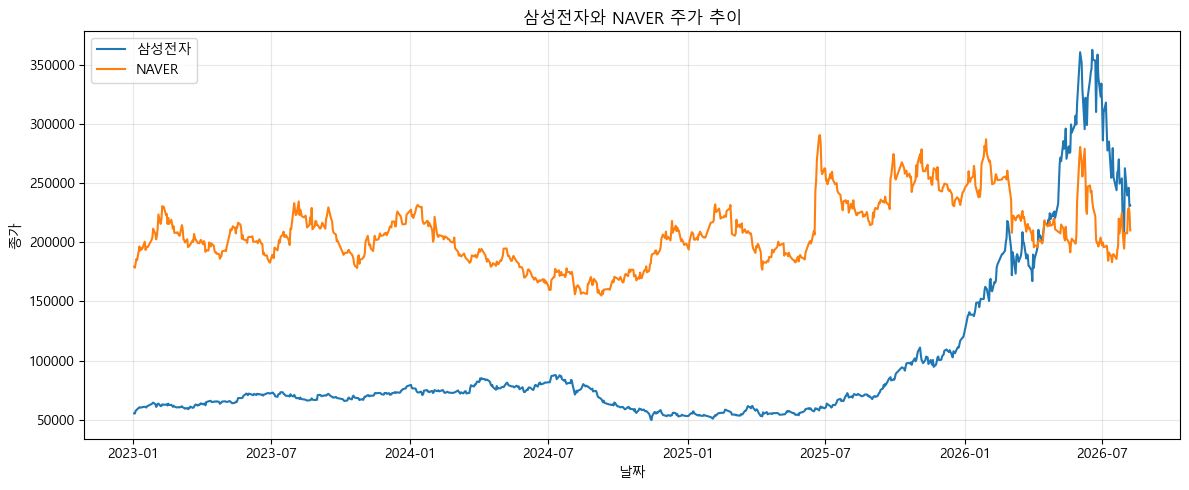

In [72]:
plt.figure(figsize=(12, 5))

for column in close.columns:
    plt.plot(
        close.index,
        close[column],
        label=column
    )

plt.title("삼성전자와 NAVER 주가 추이")
plt.xlabel("날짜")
plt.ylabel("종가")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 두 종목은 주가 수준이 다르기 때문에 직접 비교할 때는 시작 가격을 100으로 표준화하는 것이 더 이해하기 쉽습니다.

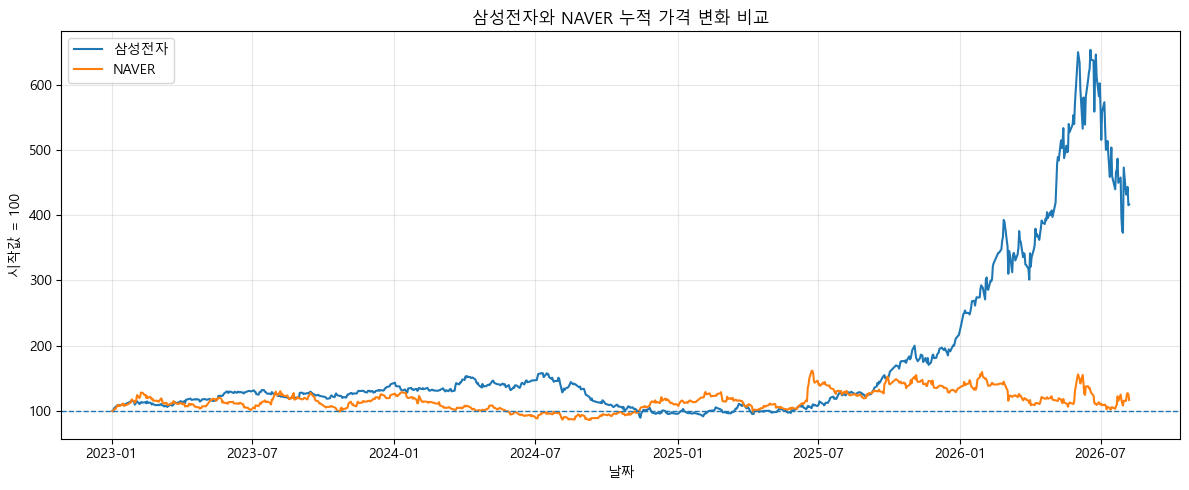

In [73]:
# 시작 가격을 100으로 변환
normalized_price = close / close.iloc[0] * 100

plt.figure(figsize=(12, 5))

for column in normalized_price.columns:
    plt.plot(
        normalized_price.index,
        normalized_price[column],
        label=column
    )

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1
)

plt.title("삼성전자와 NAVER 누적 가격 변화 비교")
plt.xlabel("날짜")
plt.ylabel("시작값 = 100")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 일별 수익률 계산
- 일별 수익률: {오늘 가격 ÷ 어제 가격} − 1

In [11]:
returns = close.pct_change().dropna()

display(returns.head())


,삼성전자,NAVER
날짜,,
2023-01-03,-0.0018,-0.0056
2023-01-04,0.0433,0.0224
2023-01-05,0.0069,0.0192
2023-01-06,0.0137,-0.0054
2023-01-09,0.0288,0.0622


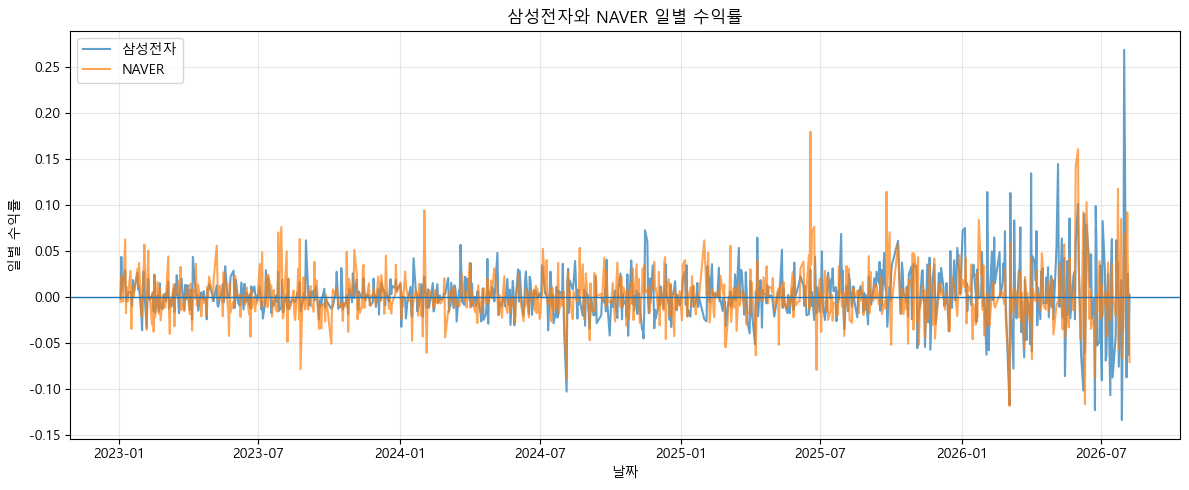

In [74]:
plt.figure(figsize=(12, 5))

for column in returns.columns:
    plt.plot(
        returns.index,
        returns[column],
        label=column,
        alpha=0.7
    )

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("삼성전자와 NAVER 일별 수익률")
plt.xlabel("날짜")
plt.ylabel("일별 수익률")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 연환산 수익률과 위험 계산
- 연환산 기대수익률: 일평균 수익률 × 252


In [75]:
trading_days = 252

# 연환산 평균수익률
annual_return = returns.mean() * trading_days

# 연환산 변동성
annual_risk = returns.std() * np.sqrt(trading_days)

risk_return_table = pd.DataFrame({
    "연환산 수익률": annual_return,
    "연환산 위험": annual_risk
})

risk_return_table["연환산 수익률(%)"] = (
    risk_return_table["연환산 수익률"] * 100
)

risk_return_table["연환산 위험(%)"] = (
    risk_return_table["연환산 위험"] * 100
)

display(
    risk_return_table[
        ["연환산 수익률(%)", "연환산 위험(%)"]
    ].round(2)
)

,연환산 수익률(%),연환산 위험(%)
삼성전자,51.2700,45.6300
NAVER,13.4900,42.6900


In [14]:
# 단순 평균수익률뿐 아니라 실제 누적성과에 가까운 기하평균 수익률 경우

In [76]:
# 복리 기준 연환산 수익률
compound_annual_return = (
    (1 + returns).prod()
    ** (trading_days / len(returns))
    - 1
)

comparison_table = pd.DataFrame({
    "산술평균 연환산 수익률(%)":
        annual_return * 100,

    "복리 연환산 수익률(%)":
        compound_annual_return * 100,

    "연환산 위험(%)":
        annual_risk * 100
})

display(comparison_table.round(2))

,산술평균 연환산 수익률(%),복리 연환산 수익률(%),연환산 위험(%)
삼성전자,51.2700,50.6500,45.6300
NAVER,13.4900,4.6100,42.6900


## 5. 50:50 포트폴리오 구성
두 종목에 각각 50%씩 투자한다고 가정합니다.

In [77]:
# 삼성전자 50%, NAVER 50%
weights = np.array([0.5, 0.5])

portfolio_return = returns.dot(weights)

portfolio_return.name = "50:50 포트폴리오"

display(portfolio_return.head())


날짜
2023-01-03   -0.0037
2023-01-04    0.0329
2023-01-05    0.0130
2023-01-06    0.0042
2023-01-09    0.0455
Name: 50:50 포트폴리오, dtype: float64

- 포트폴리오 연환산 수익률과 위험
- 연환산 위험: 일별 표준편차 × √252

In [78]:
portfolio_annual_return = (
    portfolio_return.mean() * trading_days
)

portfolio_annual_risk = (
    portfolio_return.std()
    * np.sqrt(trading_days)
)

print(
    "포트폴리오 연환산 수익률:",
    f"{portfolio_annual_return * 100:.2f}%"
)

print(
    "포트폴리오 연환산 위험:",
    f"{portfolio_annual_risk * 100:.2f}%"
)

포트폴리오 연환산 수익률: 32.38%
포트폴리오 연환산 위험: 36.22%


- 포트폴리오 위험을 공분산 행렬로 계산

In [79]:
# 연환산 공분산 행렬
annual_covariance = (
    returns.cov() * trading_days
)

portfolio_variance = (
    weights.T
    @ annual_covariance.values
    @ weights
)

portfolio_risk_cov = np.sqrt(
    portfolio_variance
)

print(
    "공분산 행렬로 계산한 포트폴리오 위험:",
    f"{portfolio_risk_cov * 100:.2f}%"
)

공분산 행렬로 계산한 포트폴리오 위험: 36.22%


- 개별 종목과 포트폴리오 비교

In [19]:
result_table = pd.DataFrame({
    "연환산 수익률(%)": [
        annual_return["삼성전자"] * 100,
        annual_return["NAVER"] * 100,
        portfolio_annual_return * 100
    ],

    "연환산 위험(%)": [
        annual_risk["삼성전자"] * 100,
        annual_risk["NAVER"] * 100,
        portfolio_annual_risk * 100
    ]
}, index=[
    "삼성전자",
    "NAVER",
    "50:50 포트폴리오"
])

display(result_table.round(2))

,연환산 수익률(%),연환산 위험(%)
삼성전자,51.2700,45.6300
NAVER,13.4900,42.6900
50:50 포트폴리오,32.3800,36.2200


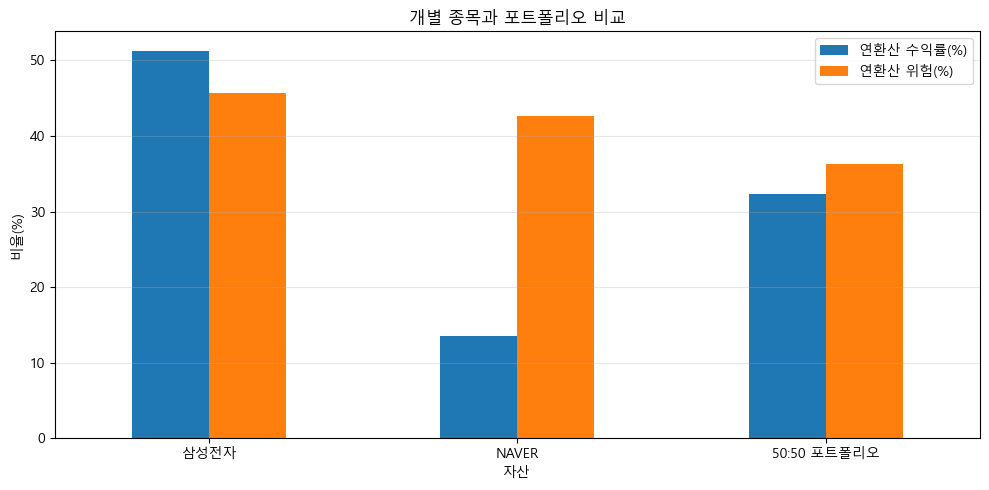

In [80]:
result_table.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("개별 종목과 포트폴리오 비교")
plt.xlabel("자산")
plt.ylabel("비율(%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 누적수익률 비교

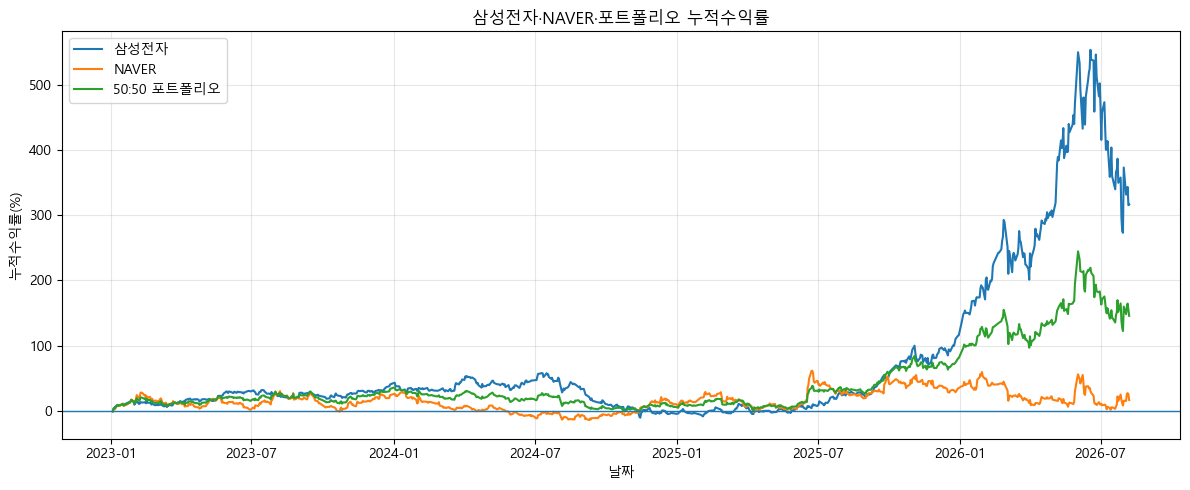

In [81]:
asset_and_portfolio_returns = returns.copy()

asset_and_portfolio_returns[
    "50:50 포트폴리오"
] = portfolio_return

cumulative_returns = (
    1 + asset_and_portfolio_returns
).cumprod() - 1

plt.figure(figsize=(12, 5))

for column in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[column] * 100,
        label=column
    )

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("삼성전자·NAVER·포트폴리오 누적수익률")
plt.xlabel("날짜")
plt.ylabel("누적수익률(%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- 삼성전자 예측용 Feature와 Target 만들기
**Feature**
- 전일 수익률
- 5일 이동평균 대비 가격 차이
- 20일 이동평균 대비 가격 차이
- 최근 5일 변동성
- 거래량 변화율

**Target**
- 다음 거래일 상승: 1
- 다음 거래일 보합 또는 하락: 0

## 11. 삼성전자 머신러닝 데이터 생성

In [82]:
# 삼성전자 OHLCV 데이터 복사
samsung = stock_data["삼성전자"].copy()

print("삼성전자 원본 데이터")
display(samsung.head())

삼성전자 원본 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2023-01-02,55500,56100,55200,55500,10031448,0.3617
2023-01-03,55400,56000,54500,55400,13547030,-0.1802
2023-01-04,55700,58000,55600,57800,20188071,4.3321
2023-01-05,58200,58800,57600,58200,15682826,0.6920
2023-01-06,58300,59400,57900,59000,17334989,1.3746


### 11-1. Feature 생성

In [83]:
# 일별 수익률
samsung["수익률"] = samsung["종가"].pct_change()

# 이동평균
samsung["MA5"] = samsung["종가"].rolling(window=5).mean()
samsung["MA20"] = samsung["종가"].rolling(window=20).mean()

# 이동평균 대비 현재 주가 비율
samsung["종가_MA5비율"] = samsung["종가"] / samsung["MA5"] - 1
samsung["종가_MA20비율"] = samsung["종가"] / samsung["MA20"] - 1

# 최근 5일 변동성
samsung["변동성5"] = samsung["수익률"].rolling(window=5).std()

# 거래량 변화율
samsung["거래량변화율"] = samsung["거래량"].pct_change()

# 당일 고가와 저가 차이
samsung["고저가변동률"] = (
    samsung["고가"] - samsung["저가"]
) / samsung["종가"]

# 다음 거래일 수익률
samsung["다음날수익률"] = samsung["수익률"].shift(-1)

# 다음날 상승 여부
# 상승: 1, 하락 또는 보합: 0
samsung["Target"] = (
    samsung["다음날수익률"] > 0
).astype(int)

# 무한대 값을 결측값으로 변경
samsung = samsung.replace(
    [np.inf, -np.inf],
    np.nan
)

# 결측값 제거
samsung = samsung.dropna()

print("Feature 생성 후 데이터 크기:", samsung.shape)

display(samsung.head())

Feature 생성 후 데이터 크기: (858, 16)


,시가,고가,저가,종가,거래량,등락률,수익률,MA5,MA20,종가_MA5비율,종가_MA20비율,변동성5,거래량변화율,고저가변동률,다음날수익률,Target
날짜,,,,,,,,,,,,,,,,
2023-01-31,63500,63700,61000,61000,29746731,-3.6335,-0.0363,"63,240.0000","60,540.0000",-0.0354,0.0076,0.0252,0.4168,0.0443,0.0131,1
2023-02-01,62600,62700,61000,61800,18570133,1.3115,0.0131,"62,920.0000","60,855.0000",-0.0178,0.0155,0.0221,-0.3757,0.0275,0.0275,1
2023-02-02,63200,63900,62600,63500,23285983,2.7508,0.0275,"62,840.0000","61,260.0000",0.0105,0.0366,0.0263,0.2539,0.0205,0.0047,1
2023-02-03,63900,64000,63000,63800,15194598,0.4724,0.0047,"62,680.0000","61,560.0000",0.0179,0.0364,0.0257,-0.3475,0.0157,-0.0345,0
2023-02-06,62800,63000,61600,61600,15529356,-3.4483,-0.0345,"62,340.0000","61,730.0000",-0.0119,-0.0021,0.0289,0.0220,0.0227,0.0049,1


## 12. 입력변수와 목표변수 설정

In [84]:
features = [
    "수익률",
    "종가_MA5비율",
    "종가_MA20비율",
    "변동성5",
    "거래량변화율",
    "고저가변동률"
]

X = samsung[features]
y = samsung["Target"]

print("입력 데이터 크기:", X.shape)
print("목표 데이터 크기:", y.shape)

display(X.head())

입력 데이터 크기: (858, 6)
목표 데이터 크기: (858,)


,수익률,종가_MA5비율,종가_MA20비율,변동성5,거래량변화율,고저가변동률
날짜,,,,,,
2023-01-31,-0.0363,-0.0354,0.0076,0.0252,0.4168,0.0443
2023-02-01,0.0131,-0.0178,0.0155,0.0221,-0.3757,0.0275
2023-02-02,0.0275,0.0105,0.0366,0.0263,0.2539,0.0205
2023-02-03,0.0047,0.0179,0.0364,0.0257,-0.3475,0.0157
2023-02-06,-0.0345,-0.0119,-0.0021,0.0289,0.0220,0.0227


### 12.1상승·하락 비율 확인

In [85]:
target_ratio = y.value_counts().sort_index()

target_ratio.index = [
    "하락·보합(0)",
    "상승(1)"
]

display(target_ratio.to_frame("관측치 수"))

,관측치 수
하락·보합(0),428
상승(1),430


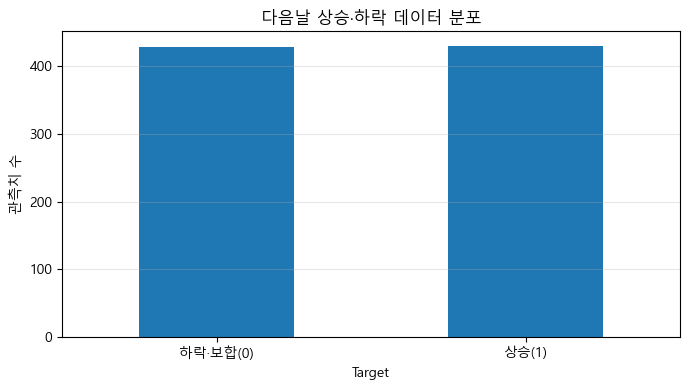

In [86]:
target_ratio.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("다음날 상승·하락 데이터 분포")
plt.xlabel("Target")
plt.ylabel("관측치 수")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. 학습 데이터와 평가 데이터 분리

In [87]:
# 앞의 80%를 학습 데이터,
# 뒤의 20%를 평가 데이터로 사용
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("학습기간")
print(X_train.index.min(), "~", X_train.index.max())

print("\n평가기간")
print(X_test.index.min(), "~", X_test.index.max())

print("\n학습 데이터:", X_train.shape)
print("평가 데이터:", X_test.shape)

학습기간
2023-01-31 00:00:00 ~ 2025-11-21 00:00:00

평가기간
2025-11-24 00:00:00 ~ 2026-08-06 00:00:00

학습 데이터: (686, 6)
평가 데이터: (172, 6)


## 14. 의사결정나무 분류모델 학습

In [88]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_pred = tree_model.predict(X_test)

print("의사결정나무 학습 완료")

의사결정나무 학습 완료


## 15. 의사결정나무 성능평가와 Feature Importance

In [89]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

tree_precision = precision_score(
    y_test,
    tree_pred,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    tree_pred,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    tree_pred,
    zero_division=0
)

print(
    f"Accuracy : {tree_accuracy:.4f}"
)

print(
    f"Precision: {tree_precision:.4f}"
)

print(
    f"Recall   : {tree_recall:.4f}"
)

print(
    f"F1-score : {tree_f1:.4f}"
)

Accuracy : 0.5058
Precision: 0.5537
Recall   : 0.6837
F1-score : 0.6119


### 15.1 분류 결과표

In [30]:
print(
    classification_report(
        y_test,
        tree_pred,
        target_names=[
            "하락·보합",
            "상승"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       하락·보합       0.39      0.27      0.32        74
          상승       0.55      0.68      0.61        98

    accuracy                           0.51       172
   macro avg       0.47      0.48      0.47       172
weighted avg       0.48      0.51      0.49       172



### 15.2 혼동행렬

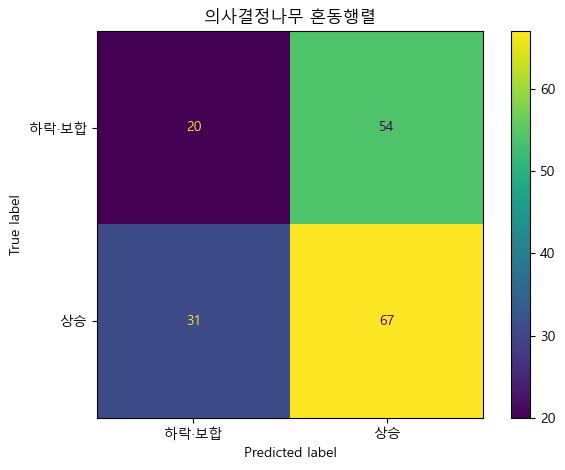

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    tree_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "하락·보합",
        "상승"
    ]
)

disp.plot(
    values_format="d"
)

plt.title("의사결정나무 혼동행렬")
plt.tight_layout()
plt.show()

### 15.3 의사결정나무 시각화

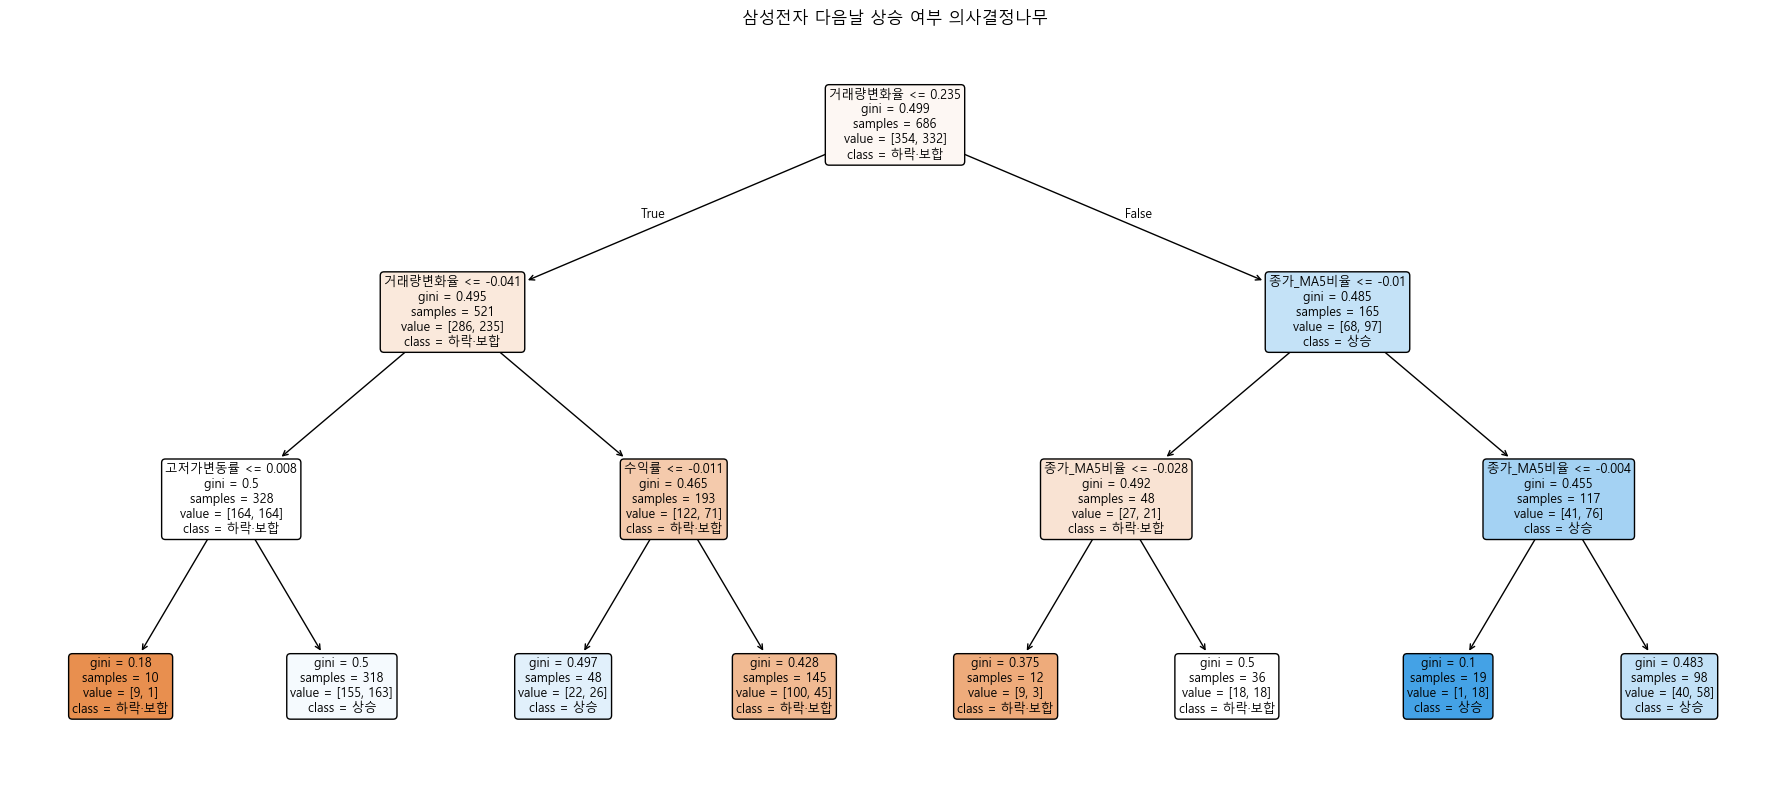

In [91]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=[
        "하락·보합",
        "상승"
    ],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("삼성전자 다음날 상승 여부 의사결정나무")
plt.tight_layout()
plt.show()

### 15.4 Feature Importance 확인

In [92]:
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=features
).sort_values(ascending=False)

display(
    feature_importance.to_frame(
        "중요도"
    )
)

,중요도
거래량변화율,0.3676
종가_MA5비율,0.3378
수익률,0.1588
고저가변동률,0.1358
종가_MA20비율,0.0000
변동성5,0.0000


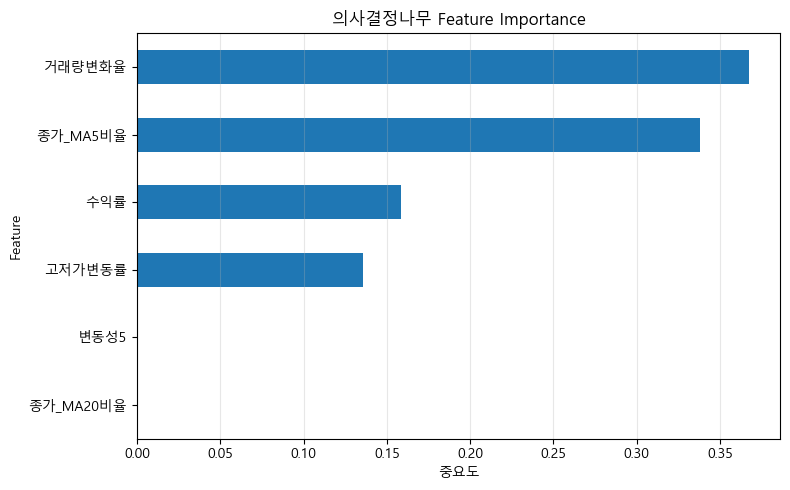

In [34]:
feature_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("의사결정나무 Feature Importance")
plt.xlabel("중요도")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

- 중요도가 높다는 것은 의사결정나무가 상승과 하락을 구분할 때 해당 변수를 상대적으로 많이 활용했다는 의미입니다. 
- 인과관계를 의미하지는 않습니다.

### 15.5 실제값과 예측값 비교

In [93]:
tree_result = pd.DataFrame({
    "실제값": y_test,
    "예측값": tree_pred
}, index=y_test.index)

tree_result["예측정확"] = (
    tree_result["실제값"]
    == tree_result["예측값"]
)

display(tree_result.head(20))

,실제값,예측값,예측정확
날짜,,,
2025-11-24,1,1,True
2025-11-25,1,1,True
2025-11-26,1,1,True
2025-11-27,0,1,False
2025-11-28,1,1,True
2025-12-01,1,1,True
2025-12-02,1,1,True
2025-12-03,1,0,False
2025-12-04,1,1,True


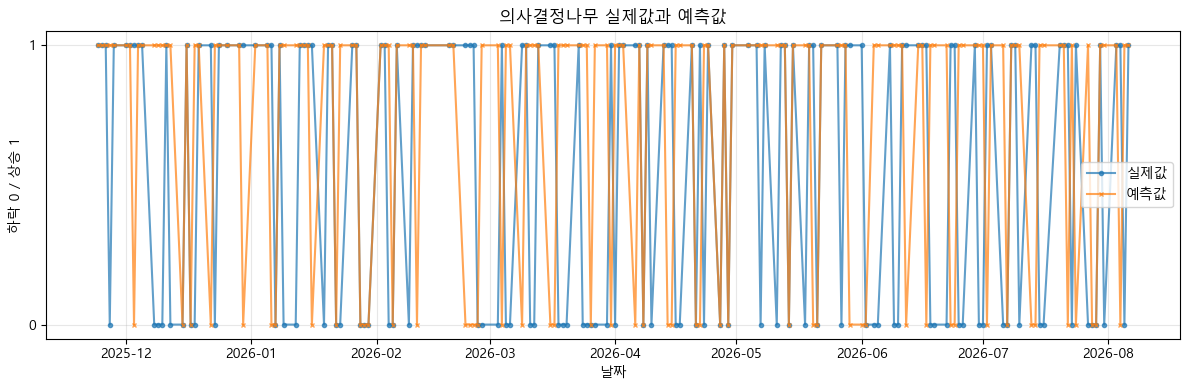

In [94]:
plt.figure(figsize=(12, 4))

plt.plot(
    tree_result.index,
    tree_result["실제값"],
    label="실제값",
    marker="o",
    markersize=3,
    alpha=0.7
)

plt.plot(
    tree_result.index,
    tree_result["예측값"],
    label="예측값",
    marker="x",
    markersize=3,
    alpha=0.7
)

plt.title("의사결정나무 실제값과 예측값")
plt.xlabel("날짜")
plt.ylabel("하락 0 / 상승 1")
plt.yticks([0, 1])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 심화 실습: LSTM
LSTM은 최근 여러 거래일의 Feature 흐름을 한 묶음(sequence)으로 학습합니다.

> 아래 셀은 **위에서부터 순서대로 한 번씩 실행**하도록 정리했습니다.


In [37]:
# # 사전 점검
# TensorFlow 환경부터 실제로 다시 설치해야 합니다.
# Jupyter에서 새 셀을 만들고 아래를 순서대로 하나씩 실행하세요.
# %pip uninstall -y tensorflow tensorflow-intel tensorflow-cpu keras ml-dtypes
# 그다음:
# %pip uninstall -y numpy
# 그다음:
# %pip install numpy==1.26.4
# 그리고:
# %pip install tensorflow==2.15.1
# TensorFlow 2.15.1은 Python 3.9를 지원하고 Windows용 CPython 3.9 패키지도 제공됩니다. Windows 네이티브 CPU 환경에서는 pip install tensorflow 방식이 공식 설치 방법입니다.
# 설치가 모두 끝났으면 반드시 커널을 재시작하세요.
# Kernel
# → Restart Kernel
# 재시작 직후에는 다른 셀을 실행하지 말고 이것만 테스트합니다.

# import numpy as np
# import tensorflow as tf

# print("NumPy:", np.__version__)
# print("TensorFlow:", tf.__version__)

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
# from tensorflow.keras.callbacks import EarlyStopping

# print("TensorFlow / Keras 정상 작동")

# 정상이라면:

# NumPy: 1.26.4
# TensorFlow: 2.15.1
# TensorFlow / Keras 정상 작동까지 나와야 합니다.

## 16. LSTM 실습 준비

In [38]:
# LSTM에 필요한 라이브러리를 한 번에 불러옵니다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow 버전:", tf.__version__)
print("LSTM 라이브러리 준비 완료")



TensorFlow 버전: 2.15.1
LSTM 라이브러리 준비 완료


## 17. LSTM 학습 데이터 준비

In [39]:
# LSTM에 사용할 Feature
lstm_features = [
    "수익률",
    "종가_MA5비율",
    "종가_MA20비율",
    "변동성5",
    "거래량변화율",
    "고저가변동률"
]

# 필요한 열이 모두 존재하는지 확인
required_cols = lstm_features + ["Target"]
missing_cols = [col for col in required_cols if col not in samsung.columns]
if missing_cols:
    raise ValueError(f"samsung 데이터에 필요한 열이 없습니다: {missing_cols}")

# 결측치를 제거한 뒤 X와 y를 같은 행 기준으로 생성
lstm_data = samsung[required_cols].dropna().copy()

lstm_X_original = lstm_data[lstm_features].copy()
lstm_y_original = lstm_data["Target"].astype(int).copy()

print("LSTM 전체 X:", lstm_X_original.shape)
print("LSTM 전체 y:", lstm_y_original.shape)
print("Target 값:", sorted(lstm_y_original.unique()))


LSTM 전체 X: (858, 6)
LSTM 전체 y: (858,)
Target 값: [0, 1]


### 학습·평가 구간 분리


In [40]:
# 시계열 순서를 유지하면서 앞 80%는 학습, 뒤 20%는 평가에 사용
split_index = int(len(lstm_X_original) * 0.8)

X_train_raw = lstm_X_original.iloc[:split_index].copy()
X_test_raw = lstm_X_original.iloc[split_index:].copy()
y_train_raw = lstm_y_original.iloc[:split_index].copy()
y_test_raw = lstm_y_original.iloc[split_index:].copy()

print("LSTM 학습 데이터:", X_train_raw.shape)
print("LSTM 평가 데이터:", X_test_raw.shape)


LSTM 학습 데이터: (686, 6)
LSTM 평가 데이터: (172, 6)


## 18. Feature 표준화


In [41]:
# 학습 데이터로만 scaler를 학습하여 데이터 누수를 방지
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)


X_train_scaled: (686, 6)
X_test_scaled : (172, 6)


## 19. LSTM 시퀀스 데이터 생성


In [52]:
def create_sequences(X, y, sequence_length=20):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y)

    X_seq = []
    y_seq = []

    for i in range(sequence_length, len(X)):
        X_seq.append(X[i-sequence_length:i])
        y_seq.append(y[i])

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)

sequence_length = 20

X_train_lstm, y_train_lstm = create_sequences(
    X_train_scaled, y_train_raw.to_numpy(), sequence_length
)
X_test_lstm, y_test_lstm = create_sequences(
    X_test_scaled, y_test_raw.to_numpy(), sequence_length
)

print("X_train_lstm:", X_train_lstm.shape)
print("y_train_lstm:", y_train_lstm.shape)
print("X_test_lstm :", X_test_lstm.shape)
print("y_test_lstm :", y_test_lstm.shape)

assert X_train_lstm.ndim == 3
assert X_test_lstm.ndim == 3
assert len(X_train_lstm) == len(y_train_lstm)
assert len(X_test_lstm) == len(y_test_lstm)


X_train_lstm: (666, 20, 6)
y_train_lstm: (666,)
X_test_lstm : (152, 20, 6)
y_test_lstm : (152,)


In [53]:
import numpy as np
import tensorflow as tf

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow / Keras 정상 작동")

NumPy: 1.26.4
TensorFlow: 2.15.1
TensorFlow / Keras 정상 작동


## 20. LSTM 모델 생성


In [54]:
# ============================================================
# 20. LSTM 모델 생성 - 독립 실행 가능 버전
# ============================================================
# 이 셀은 16~19번 셀의 일부가 실행되지 않았더라도 필요한 객체를 다시 준비합니다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# TensorFlow 로딩 여부를 안전하게 확인합니다.
TF_AVAILABLE = True
TF_ERROR = None
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except Exception as e:
    TF_AVAILABLE = False
    TF_ERROR = e
    print("[주의] TensorFlow를 불러오지 못했습니다.")
    print("오류 종류:", type(e).__name__)
    print("오류 내용:", e)
    print("\nPython 3.9 환경에서 NumPy/TensorFlow 충돌이 의심되면 새 셀에서 다음을 실행하세요:")
    print('%pip install --upgrade --force-reinstall "numpy<2" "tensorflow==2.15.1" "ml-dtypes==0.2.0"')
    print("설치 후 반드시 커널을 재시작하고 위에서부터 다시 실행하세요.")

# 이전 셀에서 LSTM 시퀀스가 만들어지지 않았다면 여기서 다시 생성합니다.
if TF_AVAILABLE:
    np.random.seed(42)
    tf.random.set_seed(42)

    if "X_train_lstm" not in globals() or "y_train_lstm" not in globals():
        if "samsung" not in globals():
            raise RuntimeError(
                "'samsung' 데이터프레임이 없습니다. 데이터 전처리 단계까지 먼저 실행하세요."
            )

        lstm_features = [
            "수익률",
            "종가_MA5비율",
            "종가_MA20비율",
            "변동성5",
            "거래량변화율",
            "고저가변동률"
        ]

        required_cols = lstm_features + ["Target"]
        missing_cols = [c for c in required_cols if c not in samsung.columns]
        if missing_cols:
            raise RuntimeError(
                "LSTM에 필요한 컬럼이 없습니다: " + ", ".join(missing_cols)
            )

        lstm_data = samsung[required_cols].dropna().copy()
        lstm_X_original = lstm_data[lstm_features].copy()
        lstm_y_original = lstm_data["Target"].astype(int).copy()

        split_index = int(len(lstm_X_original) * 0.8)
        X_train_raw = lstm_X_original.iloc[:split_index].copy()
        X_test_raw = lstm_X_original.iloc[split_index:].copy()
        y_train_raw = lstm_y_original.iloc[:split_index].copy()
        y_test_raw = lstm_y_original.iloc[split_index:].copy()

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw)
        X_test_scaled = scaler.transform(X_test_raw)

        def create_sequences(X, y, sequence_length=20):
            X = np.asarray(X, dtype=np.float32)
            y = np.asarray(y, dtype=np.float32)
            X_seq, y_seq = [], []
            for i in range(sequence_length, len(X)):
                X_seq.append(X[i-sequence_length:i])
                y_seq.append(y[i])
            return (
                np.asarray(X_seq, dtype=np.float32),
                np.asarray(y_seq, dtype=np.float32)
            )

        sequence_length = 20
        X_train_lstm, y_train_lstm = create_sequences(
            X_train_scaled, y_train_raw.to_numpy(), sequence_length
        )
        X_test_lstm, y_test_lstm = create_sequences(
            X_test_scaled, y_test_raw.to_numpy(), sequence_length
        )
    else:
        sequence_length = X_train_lstm.shape[1]

    if X_train_lstm.ndim != 3 or X_test_lstm.ndim != 3:
        raise RuntimeError("LSTM 입력 데이터는 3차원이어야 합니다.")
    if len(X_train_lstm) == 0 or len(X_test_lstm) == 0:
        raise RuntimeError("LSTM 시퀀스 데이터가 비어 있습니다.")

    n_features = X_train_lstm.shape[2]

    lstm_model = Sequential([
        Input(shape=(sequence_length, n_features)),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    lstm_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    print("TensorFlow 버전:", tf.__version__)
    print("X_train_lstm:", X_train_lstm.shape)
    print("X_test_lstm :", X_test_lstm.shape)
    print("sequence_length:", sequence_length)
    print("n_features:", n_features)
    lstm_model.summary()
else:
    lstm_model = None


TensorFlow 버전: 2.15.1
X_train_lstm: (666, 20, 6)
X_test_lstm : (152, 20, 6)
sequence_length: 20
n_features: 6
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 32)                4992      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dropout_3 (Dropout)         (None, 16)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 5537 (21.63 KB)
Trainable params: 5537 (21.63 KB)
Non-trainabl

In [55]:
import sys

print(sys.version)
print(sys.executable)

3.9.11 (tags/v3.9.11:2de452f, Mar 16 2022, 14:33:45) [MSC v.1929 64 bit (AMD64)]
C:\Users\JYB\AppData\Local\Programs\Python\Python39\python.exe


# 21. LSTM 모델 학습

In [56]:
# ============================================================
# 21. LSTM 모델 학습
# ============================================================
if globals().get("TF_AVAILABLE", False) and globals().get("lstm_model") is not None:
    from tensorflow.keras.callbacks import EarlyStopping

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = lstm_model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=1
    )

    print("LSTM 학습 완료")
    print("history keys:", list(history.history.keys()))
else:
    history = None
    print("TensorFlow가 준비되지 않아 LSTM 학습을 건너뜁니다.")


Epoch 1/50


17/17 [==============================] - 10s 138ms/step - loss: 0.6948 - accuracy: 0.4831 - val_loss: 0.6950 - val_accuracy: 0.4925
Epoch 2/50
17/17 [==============================] - 1s 46ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6983 - val_accuracy: 0.4851
Epoch 3/50
17/17 [==============================] - 0s 28ms/step - loss: 0.6900 - accuracy: 0.5226 - val_loss: 0.7024 - val_accuracy: 0.4403
Epoch 4/50
17/17 [==============================] - 1s 30ms/step - loss: 0.6842 - accuracy: 0.5752 - val_loss: 0.7075 - val_accuracy: 0.4254
Epoch 5/50
17/17 [==============================] - 0s 22ms/step - loss: 0.6833 - accuracy: 0.5714 - val_loss: 0.7156 - val_accuracy: 0.4254
Epoch 6/50
17/17 [==============================] - 0s 23ms/step - loss: 0.6779 - accuracy: 0.5771 - val_loss: 0.7245 - val_accuracy: 0.4328
LSTM 학습 완료
history keys: ['loss', 'accuracy', 'val_loss', 'val_accuracy']


## 22. LSTM 학습 과정 시각화


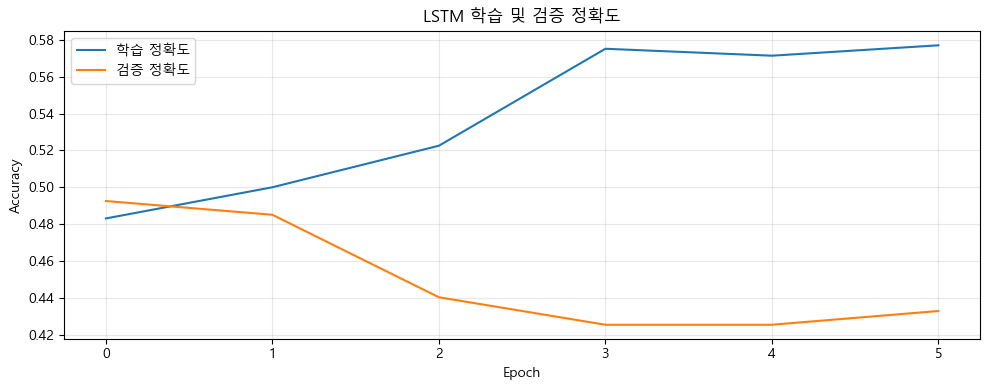

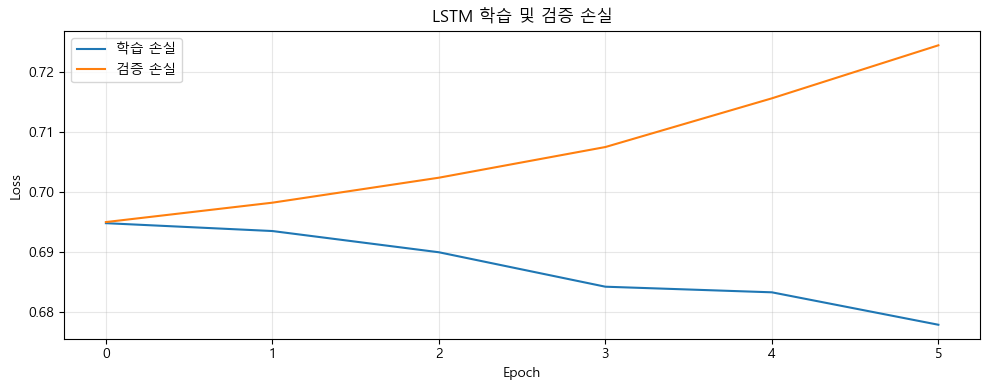

In [57]:
# ============================================================
# 22. LSTM 학습 과정 시각화
# ============================================================
import matplotlib.pyplot as plt

if globals().get("history") is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["accuracy"], label="학습 정확도")
    plt.plot(history.history["val_accuracy"], label="검증 정확도")
    plt.title("LSTM 학습 및 검증 정확도")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="학습 손실")
    plt.plot(history.history["val_loss"], label="검증 손실")
    plt.title("LSTM 학습 및 검증 손실")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("학습 이력이 없어 그래프를 생략합니다. 20~21번 셀의 메시지를 확인하세요.")


## 23. LSTM 예측


In [58]:
# ============================================================
# 23. LSTM 예측
# ============================================================
if globals().get("history") is not None and globals().get("lstm_model") is not None:
    lstm_probability = lstm_model.predict(X_test_lstm, verbose=0).flatten()
    lstm_pred = (lstm_probability >= 0.5).astype(int)
    print("LSTM 예측 완료")
    print("예측 개수:", len(lstm_pred))
else:
    lstm_probability = None
    lstm_pred = None
    print("학습된 LSTM 모델이 없어 예측을 생략합니다.")


LSTM 예측 완료
예측 개수: 152


## 24. LSTM 성능평가


In [59]:
# ============================================================
# 24. LSTM 성능평가
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

if globals().get("lstm_pred") is not None:
    lstm_accuracy = accuracy_score(y_test_lstm, lstm_pred)
    lstm_precision = precision_score(y_test_lstm, lstm_pred, zero_division=0)
    lstm_recall = recall_score(y_test_lstm, lstm_pred, zero_division=0)
    lstm_f1 = f1_score(y_test_lstm, lstm_pred, zero_division=0)

    print(f"Accuracy : {lstm_accuracy:.4f}")
    print(f"Precision: {lstm_precision:.4f}")
    print(f"Recall   : {lstm_recall:.4f}")
    print(f"F1-score : {lstm_f1:.4f}")
    print("\nClassification Report")
    print(classification_report(
        y_test_lstm,
        lstm_pred,
        target_names=["하락·보합", "상승"],
        zero_division=0
    ))
else:
    lstm_accuracy = lstm_precision = lstm_recall = lstm_f1 = np.nan
    print("LSTM 예측값이 없어 성능평가를 생략합니다.")


Accuracy : 0.5592
Precision: 0.5655
Recall   : 0.9535
F1-score : 0.7100

Classification Report
              precision    recall  f1-score   support

       하락·보합       0.43      0.05      0.08        66
          상승       0.57      0.95      0.71        86

    accuracy                           0.56       152
   macro avg       0.50      0.50      0.40       152
weighted avg       0.51      0.56      0.44       152



## 25. LSTM 혼동행렬


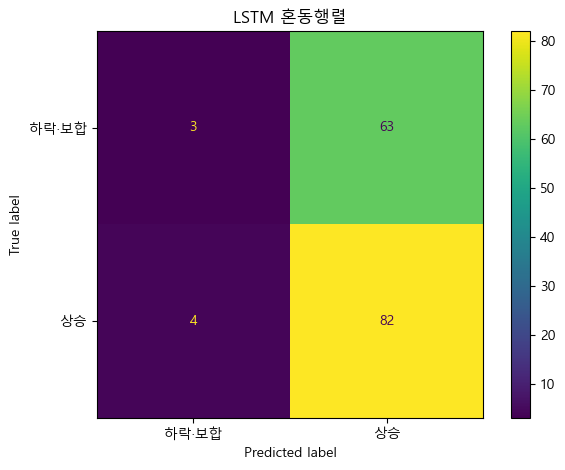

In [60]:
# ============================================================
# 25. LSTM 혼동행렬
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if globals().get("lstm_pred") is not None:
    lstm_cm = confusion_matrix(y_test_lstm, lstm_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=lstm_cm,
        display_labels=["하락·보합", "상승"]
    )
    disp.plot(values_format="d")
    plt.title("LSTM 혼동행렬")
    plt.tight_layout()
    plt.show()
else:
    print("LSTM 예측값이 없어 혼동행렬을 생략합니다.")


## 26. LSTM 예측 결과 확인


,실제값,예측값,상승예측확률
날짜,,,
2025-12-22,1,1,0.5517
2025-12-23,0,1,0.5360
2025-12-24,1,1,0.5325
2025-12-26,1,1,0.5216
2025-12-29,1,1,0.5416
2025-12-30,1,1,0.5459
2026-01-02,1,1,0.5493
2026-01-05,1,1,0.5383
2026-01-06,1,1,0.5599


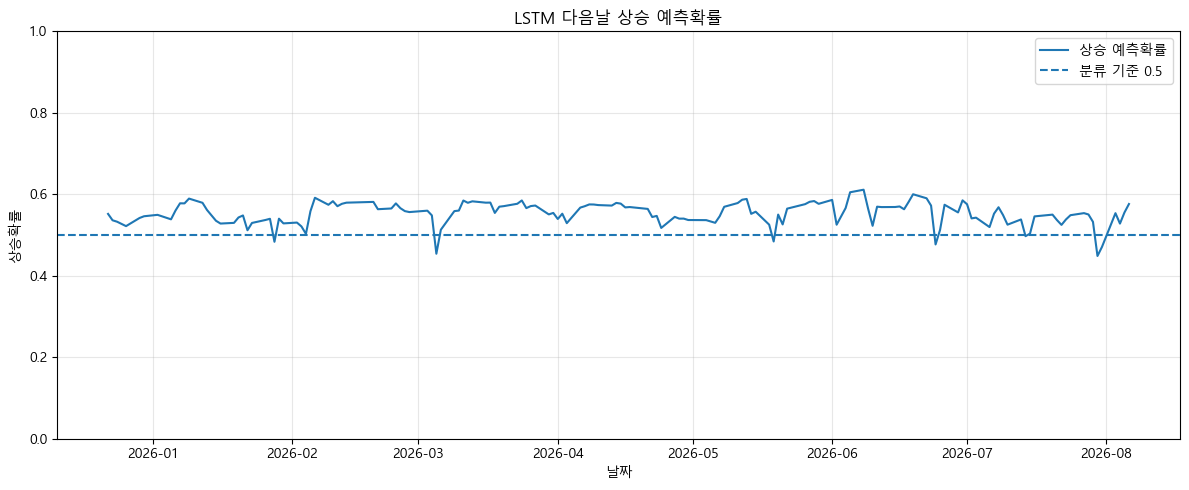

In [61]:
# ============================================================
# 26. LSTM 예측 결과 확인
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

if globals().get("lstm_pred") is not None:
    # y_test_raw이 없을 경우 원본 인덱스를 안전하게 복구합니다.
    if "y_test_raw" not in globals():
        split_index = int(len(lstm_y_original) * 0.8)
        y_test_raw = lstm_y_original.iloc[split_index:].copy()

    lstm_test_dates = y_test_raw.index[sequence_length:]
    n = min(
        len(lstm_test_dates), len(y_test_lstm),
        len(lstm_pred), len(lstm_probability)
    )

    lstm_result = pd.DataFrame({
        "실제값": y_test_lstm[:n].astype(int),
        "예측값": lstm_pred[:n],
        "상승예측확률": lstm_probability[:n]
    }, index=lstm_test_dates[:n])

    display(lstm_result.head(20))

    plt.figure(figsize=(12, 5))
    plt.plot(lstm_result.index, lstm_result["상승예측확률"], label="상승 예측확률")
    plt.axhline(y=0.5, linestyle="--", label="분류 기준 0.5")
    plt.title("LSTM 다음날 상승 예측확률")
    plt.xlabel("날짜")
    plt.ylabel("상승확률")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    lstm_result = None
    print("LSTM 예측값이 없어 결과 표와 그래프를 생략합니다.")


## 27. 의사결정나무와 LSTM 비교


,Accuracy,Precision,Recall,F1-score
Decision Tree,0.5058,0.5537,0.6837,0.6119
LSTM,0.5592,0.5655,0.9535,0.7100


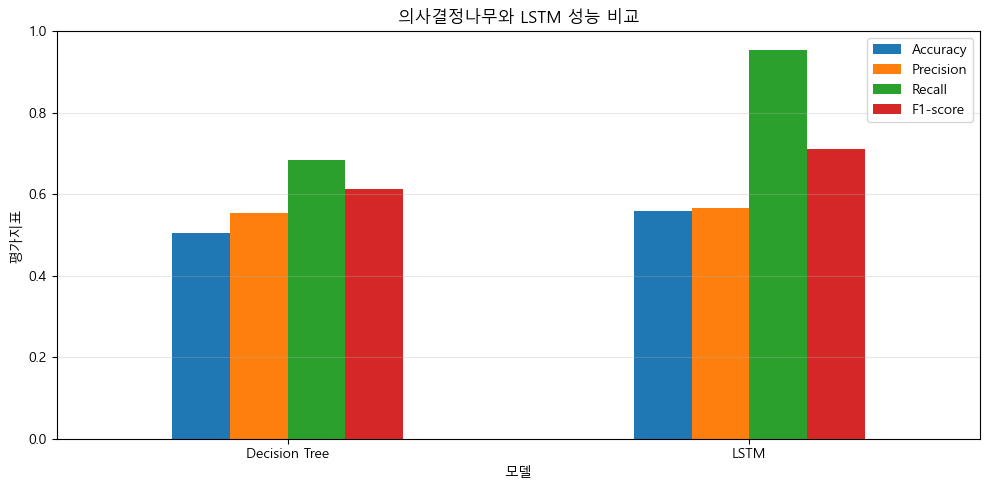

In [62]:
# ============================================================
# 27. 의사결정나무와 LSTM 비교
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_tree_metrics = ["tree_accuracy", "tree_precision", "tree_recall", "tree_f1"]
can_compare = all(name in globals() for name in required_tree_metrics)
can_compare = can_compare and np.isfinite(globals().get("lstm_accuracy", np.nan))

if can_compare:
    model_comparison = pd.DataFrame({
        "Accuracy": [tree_accuracy, lstm_accuracy],
        "Precision": [tree_precision, lstm_precision],
        "Recall": [tree_recall, lstm_recall],
        "F1-score": [tree_f1, lstm_f1]
    }, index=["Decision Tree", "LSTM"])

    display(model_comparison.round(4))
    model_comparison.plot(kind="bar", figsize=(10, 5))
    plt.title("의사결정나무와 LSTM 성능 비교")
    plt.xlabel("모델")
    plt.ylabel("평가지표")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("의사결정나무 또는 LSTM 평가값이 준비되지 않아 모델 비교를 생략합니다.")


### 해석 시 주의사항
- 의사결정나무는 구조와 Feature Importance를 쉽게 설명할 수 있습니다.
- LSTM은 최근 20일처럼 연속된 시계열 정보를 학습합니다.
- 주식의 단기 방향은 잡음이 크므로 학습 정확도만으로 모델 품질을 판단하면 안 됩니다.
- 실제 투자에는 거래비용, 과적합, 미래정보 사용 여부 등을 추가로 검토해야 합니다.


# 의사결정나무 - (삼성전자) 향후 5거래일 상승/하락 예측

In [64]:
# ============================================================
# 의사결정나무 - 향후 5거래일 상승/하락 예측
# ============================================================

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ------------------------------------------------------------
# 1. 사용할 Feature
# ------------------------------------------------------------

tree_features = [
    "수익률",
    "종가_MA5비율",
    "종가_MA20비율",
    "변동성5",
    "거래량변화율",
    "고저가변동률"
]

future_days = 5


# ------------------------------------------------------------
# 2. 원본 데이터 복사
# ------------------------------------------------------------

tree_future_data = samsung.copy()


# ------------------------------------------------------------
# 3. 1~5거래일 후 Target 생성
# ------------------------------------------------------------
# 현재 종가와 n거래일 뒤 종가를 비교
#
# Target_1 : 1거래일 후 현재보다 상승 = 1
# Target_2 : 2거래일 후 현재보다 상승 = 1
# ...
# Target_5 : 5거래일 후 현재보다 상승 = 1

for day in range(1, future_days + 1):

    future_return = (
        tree_future_data["종가"].shift(-day)
        / tree_future_data["종가"]
        - 1
    )

    tree_future_data[f"Target_{day}"] = (
        future_return > 0
    ).astype(float)

    # 실제 미래 가격이 존재하지 않는 마지막 day개 행은 NaN
    tree_future_data.loc[
        tree_future_data.index[-day:],
        f"Target_{day}"
    ] = np.nan


# ------------------------------------------------------------
# 4. 가장 최근 Feature 준비
# ------------------------------------------------------------

latest_X = (
    tree_future_data[tree_features]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .iloc[[-1]]
)

print("예측 기준일:", latest_X.index[0])

display(latest_X)


# ------------------------------------------------------------
# 5. 1~5거래일 후 각각 모델 학습
# ------------------------------------------------------------

tree_future_predictions = []

tree_models = {}

for horizon in range(1, future_days + 1):

    print()
    print("=" * 50)
    print(f"{horizon}거래일 후 의사결정나무")
    print("=" * 50)

    target_col = f"Target_{horizon}"

    # Feature + Target 데이터
    temp = tree_future_data[
        tree_features + [target_col]
    ].copy()

    # 무한대 처리
    temp = temp.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # 결측치 제거
    temp = temp.dropna()

    X = temp[tree_features]
    y = temp[target_col].astype(int)

    # --------------------------------------------------------
    # 시계열 방식 80% / 20% 분할
    # --------------------------------------------------------

    split_index = int(len(X) * 0.8)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # --------------------------------------------------------
    # 의사결정나무 생성
    # 현재 노트북과 동일한 설정
    # --------------------------------------------------------

    model = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=10,
        random_state=42
    )

    # 학습
    model.fit(
        X_train,
        y_train
    )

    # 테스트 예측
    y_pred = model.predict(
        X_test
    )

    # --------------------------------------------------------
    # 테스트 성능 확인
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    print(
        f"테스트 Accuracy: {accuracy:.4f}"
    )

    # --------------------------------------------------------
    # 최신 데이터로 미래 예측
    # --------------------------------------------------------

    future_pred = int(
        model.predict(
            latest_X
        )[0]
    )

    # 상승 확률
    probability_array = model.predict_proba(
        latest_X
    )[0]

    # 클래스 1(상승)이 모델에 존재하는지 안전하게 확인
    if 1 in model.classes_:

        class_1_index = list(
            model.classes_
        ).index(1)

        rise_probability = float(
            probability_array[class_1_index]
        )

    else:

        rise_probability = 0.0

    prediction_text = (
        "상승"
        if future_pred == 1
        else "하락·보합"
    )

    tree_future_predictions.append({
        "예측시점": f"{horizon}거래일 후",
        "상승확률": rise_probability,
        "예측": prediction_text,
        "테스트정확도": accuracy
    })

    # 모델 저장
    tree_models[horizon] = model


# ------------------------------------------------------------
# 6. 결과 DataFrame
# ------------------------------------------------------------

tree_future_result = pd.DataFrame(
    tree_future_predictions
)

tree_future_result["상승확률"] = (
    tree_future_result["상승확률"] * 100
).round(2)

tree_future_result["테스트정확도"] = (
    tree_future_result["테스트정확도"] * 100
).round(2)

print()
print("의사결정나무 향후 5거래일 예측")

display(tree_future_result)

예측 기준일: 2026-08-06 00:00:00


,수익률,종가_MA5비율,종가_MA20비율,변동성5,거래량변화율,고저가변동률
날짜,,,,,,
2026-08-06,-0.0630,-0.0542,-0.0791,0.1414,0.1561,0.0781



1거래일 후 의사결정나무
테스트 Accuracy: 0.5058

2거래일 후 의사결정나무
테스트 Accuracy: 0.5116

3거래일 후 의사결정나무
테스트 Accuracy: 0.4035

4거래일 후 의사결정나무
테스트 Accuracy: 0.3977

5거래일 후 의사결정나무
테스트 Accuracy: 0.6316

의사결정나무 향후 5거래일 예측


,예측시점,상승확률,예측,테스트정확도
0,1거래일 후,54.1700,상승,50.5800
1,2거래일 후,90.0000,상승,51.1600
2,3거래일 후,72.2200,상승,40.3500
3,4거래일 후,91.6700,상승,39.7700
4,5거래일 후,92.8600,상승,63.1600


# 향후 5거래일 (삼성전자) 상승/하락 예측 LSTM으로 학습

In [63]:
# ============================================================
# 향후 5거래일 상승/하락 예측
# - 1일 후 ~ 5일 후를 각각 별도 LSTM으로 학습
# ============================================================

import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ------------------------------------------------------------
# 1. LSTM에 사용할 Feature
# ------------------------------------------------------------

future_features = [
    "수익률",
    "종가_MA5비율",
    "종가_MA20비율",
    "변동성5",
    "거래량변화율",
    "고저가변동률"
]

sequence_length = 20
future_days = 5


# ------------------------------------------------------------
# 2. 미래 1~5일 Target 생성
# ------------------------------------------------------------
# Target_1 : 다음 거래일 상승 여부
# Target_2 : 2거래일 뒤 상승 여부
# ...
# Target_5 : 5거래일 뒤 상승 여부

future_data = samsung.copy()

for day in range(1, future_days + 1):

    future_return = (
        future_data["종가"].shift(-day)
        / future_data["종가"]
        - 1
    )

    future_data[f"Target_{day}"] = (
        future_return > 0
    ).astype(float)


# ------------------------------------------------------------
# 3. Feature 데이터 준비
# ------------------------------------------------------------

X_all = future_data[future_features].copy()

X_all = X_all.replace(
    [np.inf, -np.inf],
    np.nan
)


# ------------------------------------------------------------
# 4. 최근 실제 20일 데이터 확보
# ------------------------------------------------------------

latest_feature_data = (
    X_all
    .dropna()
    .iloc[-sequence_length:]
    .copy()
)

if len(latest_feature_data) < sequence_length:
    raise ValueError(
        "최근 20거래일 Feature 데이터가 부족합니다."
    )

print(
    "예측 기준 마지막 날짜:",
    latest_feature_data.index[-1]
)


# ------------------------------------------------------------
# 5. 1~5일 모델 학습 및 예측
# ------------------------------------------------------------

future_predictions = []

for horizon in range(1, future_days + 1):

    print()
    print("=" * 50)
    print(f"{horizon}거래일 후 모델 학습")
    print("=" * 50)

    target_col = f"Target_{horizon}"

    # Feature + Target 결측치 제거
    temp = future_data[
        future_features + [target_col]
    ].copy()

    # 미래 데이터가 없는 마지막 horizon개 행 제거
    temp.loc[
        temp.index[-horizon:],
        target_col
    ] = np.nan

    temp = temp.dropna()

    X = temp[future_features].copy()
    y = temp[target_col].astype(int).copy()

    # ----------------------------------------
    # 시계열 Train / Test 분리
    # ----------------------------------------

    split_index = int(len(X) * 0.8)

    X_train_raw = X.iloc[:split_index].copy()
    X_test_raw = X.iloc[split_index:].copy()

    y_train_raw = y.iloc[:split_index].copy()
    y_test_raw = y.iloc[split_index:].copy()

    # ----------------------------------------
    # 표준화
    # ----------------------------------------

    from sklearn.preprocessing import StandardScaler

    horizon_scaler = StandardScaler()

    X_train_scaled = horizon_scaler.fit_transform(
        X_train_raw
    )

    X_test_scaled = horizon_scaler.transform(
        X_test_raw
    )

    # ----------------------------------------
    # 시퀀스 생성 함수
    # ----------------------------------------

    def make_sequences(X, y, seq_len=20):

        X_seq = []
        y_seq = []

        X = np.asarray(
            X,
            dtype=np.float32
        )

        y = np.asarray(y)

        for i in range(
            seq_len,
            len(X)
        ):
            X_seq.append(
                X[i-seq_len:i]
            )

            y_seq.append(
                y[i]
            )

        return (
            np.asarray(
                X_seq,
                dtype=np.float32
            ),
            np.asarray(
                y_seq,
                dtype=np.float32
            )
        )


    X_train_seq, y_train_seq = make_sequences(
        X_train_scaled,
        y_train_raw.to_numpy(),
        sequence_length
    )

    X_test_seq, y_test_seq = make_sequences(
        X_test_scaled,
        y_test_raw.to_numpy(),
        sequence_length
    )

    # ----------------------------------------
    # LSTM 모델
    # ----------------------------------------

    n_features = X_train_seq.shape[2]

    model = Sequential([
        Input(
            shape=(
                sequence_length,
                n_features
            )
        ),

        LSTM(
            32,
            return_sequences=False
        ),

        Dropout(0.2),

        Dense(
            16,
            activation="relu"
        ),

        Dropout(0.2),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # ----------------------------------------
    # Early Stopping
    # ----------------------------------------

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # ----------------------------------------
    # 모델 학습
    # ----------------------------------------

    model.fit(
        X_train_seq,
        y_train_seq,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=0
    )

    # ----------------------------------------
    # 최근 20일 데이터를 같은 scaler로 변환
    # ----------------------------------------

    latest_scaled = horizon_scaler.transform(
        latest_feature_data
    )

    latest_sequence = latest_scaled.reshape(
        1,
        sequence_length,
        len(future_features)
    )

    # ----------------------------------------
    # 미래 상승확률 예측
    # ----------------------------------------

    probability = float(
        model.predict(
            latest_sequence,
            verbose=0
        )[0][0]
    )

    prediction = (
        "상승"
        if probability >= 0.5
        else "하락·보합"
    )

    future_predictions.append({
        "예측시점": f"{horizon}거래일 후",
        "상승확률": probability,
        "예측": prediction
    })


# ------------------------------------------------------------
# 6. 결과 DataFrame
# ------------------------------------------------------------

future_result = pd.DataFrame(
    future_predictions
)

future_result["상승확률"] = (
    future_result["상승확률"] * 100
).round(2)

print()
print("향후 5거래일 예측 결과")

display(future_result)

예측 기준 마지막 날짜: 2026-08-06 00:00:00

1거래일 후 모델 학습

2거래일 후 모델 학습

3거래일 후 모델 학습

4거래일 후 모델 학습

5거래일 후 모델 학습

향후 5거래일 예측 결과


,예측시점,상승확률,예측
0,1거래일 후,48.6500,하락·보합
1,2거래일 후,54.7700,상승
2,3거래일 후,38.3700,하락·보합
3,4거래일 후,18.7800,하락·보합
4,5거래일 후,54.0800,상승
